## Import Libraries and Load Dataset

In [1]:
# Import required libraries
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# Load the cleaned dataset
df = pd.read_csv('Dataset_cleaned.csv')

# Check dataset dimensions
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Display the first five rows
df.head()

Rows: 9551, Columns: 21


,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,average_cost_for_two,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenue, Poblacion, Makati City","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Task 1: Top Cuisines

**1. Determine the top three most common cuisines in the dataset.**
**2. Calculate the percentage of restaurants that serve each of the top cuisines.**

Many restaurants list multiple cuisines (comma-separated), so we count each cuisine tag a restaurant offers, not just the first-listed one.

In [2]:
# Count total restaurants
total_restaurants = len(df)

# Count each cuisine
cuisine_counter = Counter()

for entry in df['cuisines'].dropna():

    # Split multiple cuisines
    cuisines = entry.split(',')

    for cuisine in cuisines:
        cuisine = cuisine.strip()
        cuisine_counter[cuisine] += 1

# Get top 3 cuisines
top3_cuisine = cuisine_counter.most_common(3)

# Create summary DataFrame
top3_df = pd.DataFrame(top3_cuisine, columns=['cuisines', 'restaurant_count'])

# Calculate percentage of restaurants
top3_df['pct_of_restaurants'] = (top3_df['restaurant_count'] / total_restaurants * 100).round(2)

top3_df

,cuisines,restaurant_count,pct_of_restaurants
0,North Indian,3960,41.46
1,Chinese,2735,28.64
2,Fast Food,1986,20.79


## Task 2: City Analysis

**1. Identify the city with the highest number of restaurants in the dataset.**

In [3]:
# Count restaurants in each city
city_counts = df['city'].value_counts()

# Find the city with the most restaurants
top_city_by_count = city_counts.idxmax()

print(f"City with most restaurants: {top_city_by_count} ({city_counts.max()} restaurants)")

# Display top 10 cities
city_counts.head(10)

City with most restaurants: New Delhi (5473 restaurants)


city
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

**2. Calculate the average rating for restaurants in each city.**

In [4]:
# Calculate average rating for each city
city_avg_rating = df.groupby('city')['aggregate_rating'].mean().round(2)

# Display average ratings
print(city_avg_rating)

city
Abu Dhabi          4.30
Agra               3.96
Ahmedabad          4.16
Albany             3.56
Allahabad          3.40
                   ... 
Weirton            3.90
Wellington City    4.25
Winchester Bay     3.20
Yorkton            3.30
İstanbul           4.29
Name: aggregate_rating, Length: 141, dtype: float64


**3. Determine the city with the highest average rating.**

In [5]:
# Calculate and sort average rating by city
city_avg_rating = df.groupby('city')['aggregate_rating'].mean().round(2).sort_values(ascending=False)

# Display city-wise average ratings
print(city_avg_rating)

city
Inner City          4.90
Quezon City         4.80
Makati City         4.65
Pasig City          4.63
Mandaluyong City    4.62
                    ... 
New Delhi           2.44
Montville           2.40
Mc Millan           2.40
Noida               2.04
Faridabad           1.87
Name: aggregate_rating, Length: 141, dtype: float64


**Conclusion:** Inner City has the highest average restaurant rating (**4.90**), while Faridabad has the lowest (**1.87**).

## Task 3: Price Range Distribution

**1. Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants.**

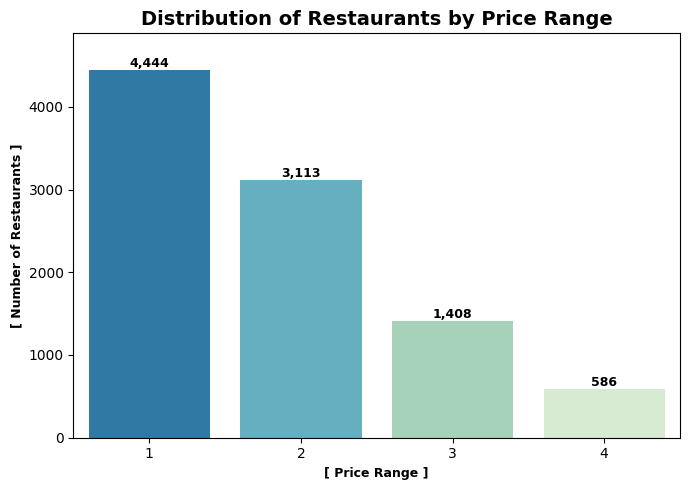

In [6]:
# Count restaurants in each price range
price_counts = df['price_range'].value_counts().sort_index()

plt.figure(figsize=(7, 5))

colors = sns.color_palette("GnBu_r", len(price_counts))

ax = sns.barplot(
    x=price_counts.index,
    y=price_counts.values,
    hue=price_counts.index,
    palette=colors,
    legend=False
)

# Add values on top of bars
for bar in ax.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Distribution of Restaurants by Price Range',fontsize=14,fontweight='bold')

plt.xlabel('[ Price Range ]', fontsize=9, fontweight='bold')
plt.ylabel('[ Number of Restaurants ]', fontsize=9, fontweight='bold')

plt.ylim(0, price_counts.max() * 1.10)

plt.tight_layout()
plt.show()

**2. Calculate the percentage of restaurants in each price range category.**

In [7]:
# Calculate percentage of restaurants in each price range
price_percentage = (df['price_range'].value_counts(normalize=True).sort_index() * 100).round(2)

# Create price range summary
price_distribution = pd.DataFrame({
    'Restaurant Count': df['price_range'].value_counts().sort_index(),
    'Percentage': price_percentage
})

price_distribution

,Restaurant Count,Percentage
price_range,,
1,4444,46.53
2,3113,32.59
3,1408,14.74
4,586,6.14


## Task 4: Online Delivery

**1. Determine the percentage of restaurants that offer online delivery.**

In [8]:
# Calculate percentage of restaurants offering online delivery
online_delivery_percentage = (df['has_online_delivery'].value_counts(normalize=True) * 100).round(2)

online_delivery_percentage

has_online_delivery
No     74.34
Yes    25.66
Name: proportion, dtype: float64


 **Conclusion:** 25.66% of restaurants offer online delivery, while 74.34% do not.


**2. Compare the average ratings of restaurants with and without online delivery.**

In [9]:
# Calculate average rating based on online delivery availability
avg_rating_delivery = (df.groupby('has_online_delivery')['aggregate_rating'].mean().round(2))

avg_rating_delivery

has_online_delivery
No     2.47
Yes    3.25
Name: aggregate_rating, dtype: float64

**Conclusion:** Restaurants with online delivery have a higher average rating (**3.25**) than restaurants without online delivery (**2.47**).